In [57]:
import pandas as pd
import os

In [58]:
data_folder = "../data"

csv_files = [
    file
    for file in os.listdir(data_folder)
    if file.endswith(".csv")
]

print(csv_files)

['aggressive_red.csv', 'bursty.csv', 'extreme.csv', 'heavy_1.csv', 'heavy_2.csv', 'large_buffer.csv', 'light_1.csv', 'moderate_1.csv', 'relaxed_red.csv', 'small_buffer.csv']


In [59]:
# Read every CSV and remember which simulation it came from

dataframes = []

for file in csv_files:
    df = pd.read_csv(os.path.join(data_folder, file))

    scenario = file.replace(".csv", "")
    df["Scenario"] = scenario

    dataframes.append(df)

print("Number of datasets loaded:", len(dataframes))

Number of datasets loaded: 10


In [60]:
combined_df["Scenario"].value_counts()

Scenario
extreme           1099
heavy_2            599
aggressive_red     432
heavy_1            432
large_buffer       432
relaxed_red        432
small_buffer       432
bursty             414
moderate_1         299
light_1            224
Name: count, dtype: int64

In [61]:
# Combine all DataFrames into one large dataset

combined_df = pd.concat(dataframes, ignore_index=True)

print(combined_df.shape)
combined_df.head()

(4795, 12)


,Time,QueueSize,QueueOccupancy,DropProbability,RandomNumber,PacketDropped,PacketsDropped,PacketsForwarded,PacketsReceived,ArrivalRate,ServiceRate,Scenario
0,0.3,0,0.000000,0.0,-1.0,0,0,0,1,3.33333,0.000000,aggressive_red
1,0.6,1,0.083333,0.0,-1.0,0,0,0,2,3.33333,0.000000,aggressive_red
2,0.9,2,0.166667,0.0,-1.0,0,0,0,3,3.33333,0.000000,aggressive_red
3,1.2,3,0.250000,0.0,-1.0,0,0,0,4,3.33333,0.000000,aggressive_red
4,1.3,2,0.166667,0.0,-1.0,0,0,1,4,3.07692,0.769231,aggressive_red


In [62]:
# Display general information about the dataset

combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4795 entries, 0 to 4794
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              4795 non-null   float64
 1   QueueSize         4795 non-null   int64  
 2   QueueOccupancy    4795 non-null   float64
 3   DropProbability   4795 non-null   float64
 4   RandomNumber      4795 non-null   float64
 5   PacketDropped     4795 non-null   int64  
 6   PacketsDropped    4795 non-null   int64  
 7   PacketsForwarded  4795 non-null   int64  
 8   PacketsReceived   4795 non-null   int64  
 9   ArrivalRate       4795 non-null   float64
 10  ServiceRate       4795 non-null   float64
 11  Scenario          4795 non-null   str    
dtypes: float64(6), int64(5), str(1)
memory usage: 492.4 KB


In [63]:
# Calculate descriptive statistics

combined_df.describe()



,Time,QueueSize,QueueOccupancy,DropProbability,RandomNumber,PacketDropped,PacketsDropped,PacketsForwarded,PacketsReceived,ArrivalRate,ServiceRate
count,4795.000000,4795.000000,4795.000000,4795.000000,4795.000000,4795.000000,4795.000000,4795.000000,4795.000000,4795.000000,4795.000000
mean,50.016966,9.468405,0.731864,0.737591,0.154770,0.565172,184.412722,49.352450,244.233577,4.854786,0.963658
std,28.508350,3.860737,0.158636,0.289452,0.686841,0.495786,200.843474,28.511686,219.157892,2.930705,0.103176
min,0.100000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,1.000000,1.041670,0.000000
25%,25.575000,6.000000,0.700000,0.500000,0.019988,0.000000,48.500000,25.000000,90.000000,3.329430,0.973451
50%,49.800000,10.000000,0.800000,0.750000,0.377752,1.000000,125.000000,49.000000,188.000000,3.333330,0.986842
75%,74.450000,11.000000,0.833333,1.000000,0.666767,1.000000,212.000000,74.000000,305.000000,5.000000,0.992908
max,100.000000,20.000000,0.916667,1.000000,0.998847,1.000000,888.000000,99.000000,1000.000000,10.000000,0.998991


In [64]:
# Count missing values in each column

combined_df.isnull().sum()

Time                0
QueueSize           0
QueueOccupancy      0
DropProbability     0
RandomNumber        0
PacketDropped       0
PacketsDropped      0
PacketsForwarded    0
PacketsReceived     0
ArrivalRate         0
ServiceRate         0
Scenario            0
dtype: int64

In [65]:
# Count dropped vs non-dropped packets

combined_df["PacketDropped"].value_counts()

PacketDropped
1    2710
0    2085
Name: count, dtype: int64

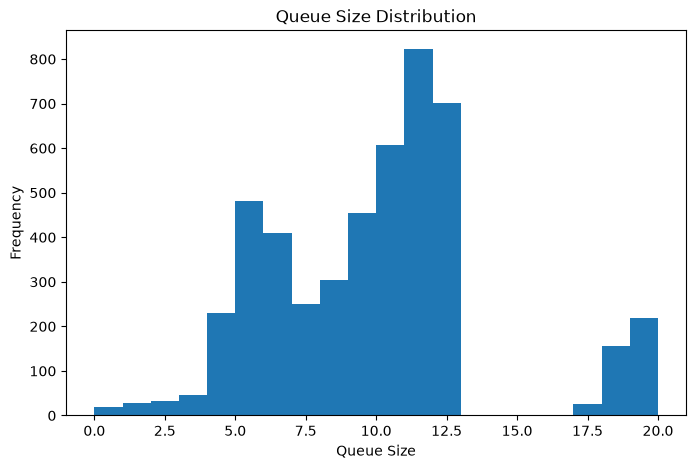

In [66]:
import matplotlib.pyplot as plt

# Plot the distribution of queue sizes

plt.figure(figsize=(8,5))
plt.hist(combined_df["QueueSize"], bins=20)

plt.title("Queue Size Distribution")
plt.xlabel("Queue Size")
plt.ylabel("Frequency")

plt.show()

In [67]:
import matplotlib.pyplot as plt

# Calculate correlations between numerical columns
correlation_matrix = combined_df.corr(numeric_only=True)

# Display the correlation matrix
correlation_matrix

,Time,QueueSize,QueueOccupancy,DropProbability,RandomNumber,PacketDropped,PacketsDropped,PacketsForwarded,PacketsReceived,ArrivalRate,ServiceRate
Time,1.000000,0.097446,0.177628,0.115276,0.082447,0.056721,0.559142,0.999921,0.644219,0.016902,0.392152
QueueSize,0.097446,1.000000,0.511790,0.381071,0.253920,0.209087,0.264488,0.097620,0.272702,0.350989,0.231485
QueueOccupancy,0.177628,0.511790,1.000000,0.649398,0.434078,0.269995,0.203606,0.175964,0.218499,0.227620,0.410610
DropProbability,0.115276,0.381071,0.649398,1.000000,0.684985,0.393275,0.315657,0.112987,0.310691,0.396379,0.284923
RandomNumber,0.082447,0.253920,0.434078,0.684985,1.000000,0.456088,0.166744,0.078533,0.167500,0.206872,0.155240
PacketDropped,0.056721,0.209087,0.269995,0.393275,0.456088,1.000000,0.255454,0.053269,0.244720,0.324490,0.111139
PacketsDropped,0.559142,0.264488,0.203606,0.315657,0.166744,0.255454,1.000000,0.561663,0.994162,0.722293,0.227265
PacketsForwarded,0.999921,0.097620,0.175964,0.112987,0.078533,0.053269,0.561663,1.000000,0.646543,0.020596,0.393783
PacketsReceived,0.644219,0.272702,0.218499,0.310691,0.167500,0.244720,0.994162,0.646543,1.000000,0.670795,0.263580
ArrivalRate,0.016902,0.350989,0.227620,0.396379,0.206872,0.324490,0.722293,0.020596,0.670795,1.000000,0.041765


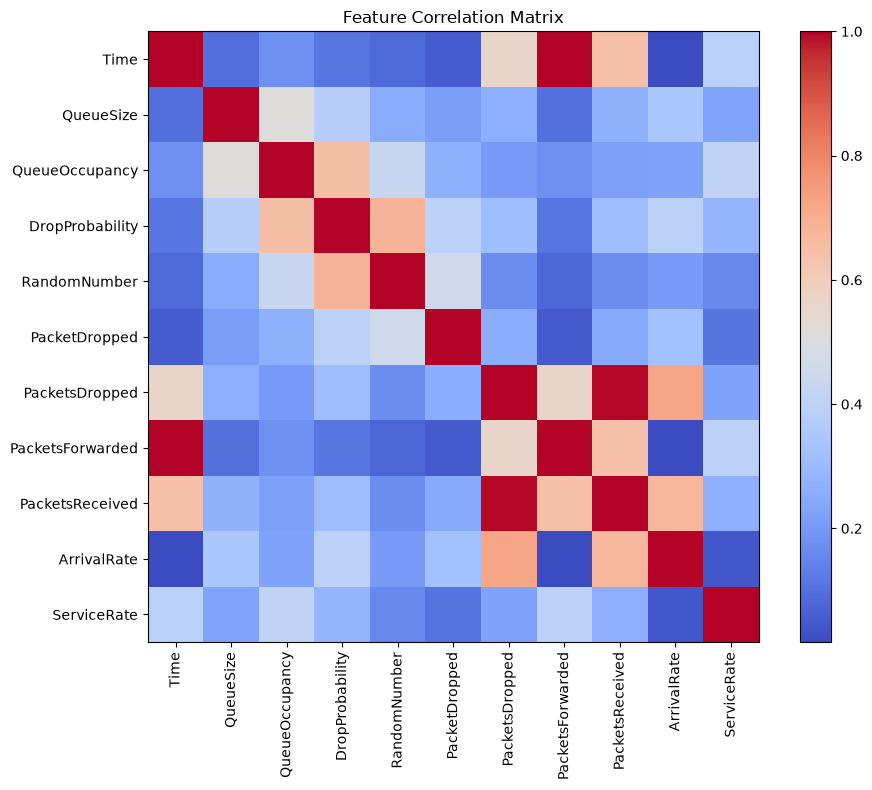

In [68]:
plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [69]:
# Show correlation of every feature with PacketDropped

correlation_matrix["PacketDropped"].sort_values(ascending=False)

PacketDropped       1.000000
RandomNumber        0.456088
DropProbability     0.393275
ArrivalRate         0.324490
QueueOccupancy      0.269995
PacketsDropped      0.255454
PacketsReceived     0.244720
QueueSize           0.209087
ServiceRate         0.111139
Time                0.056721
PacketsForwarded    0.053269
Name: PacketDropped, dtype: float64

In [70]:
# Select the input features

X = combined_df[
    [
        "QueueSize",
        "QueueOccupancy",
        "DropProbability",
        "ArrivalRate",
        "ServiceRate"
    ]
]

# Select the output label

y = combined_df["PacketDropped"]

In [71]:
print(X.head())
print()
print(y.head())

   QueueSize  QueueOccupancy  DropProbability  ArrivalRate  ServiceRate
0          0        0.000000              0.0      3.33333     0.000000
1          1        0.083333              0.0      3.33333     0.000000
2          2        0.166667              0.0      3.33333     0.000000
3          3        0.250000              0.0      3.33333     0.000000
4          2        0.166667              0.0      3.07692     0.769231

0    0
1    0
2    0
3    0
4    0
Name: PacketDropped, dtype: int64


In [72]:
from sklearn.model_selection import train_test_split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (3836, 5)
Testing samples : (959, 5)


In [75]:
from sklearn.tree import DecisionTreeClassifier

In [76]:
model = DecisionTreeClassifier(random_state=42)

In [77]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [78]:
y_pred = model.predict(X_test)

In [79]:
print(y_pred[:20])

[1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1]


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [81]:
# Evaluate the Decision Tree model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7497
Precision: 0.7846
Recall   : 0.7612
F1 Score : 0.7727


In [82]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[311 112]
 [128 408]]


In [83]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.74      0.72       423
           1       0.78      0.76      0.77       536

    accuracy                           0.75       959
   macro avg       0.75      0.75      0.75       959
weighted avg       0.75      0.75      0.75       959



In [84]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,ArrivalRate,0.413768
4,ServiceRate,0.386650
1,QueueOccupancy,0.072281
2,DropProbability,0.065694
0,QueueSize,0.061607


In [85]:
# Import the Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

In [86]:
# Create the Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [87]:
# Train the Random Forest model

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [88]:
# Predict packet drops using the Random Forest

rf_pred = rf_model.predict(X_test)

In [89]:
# Evaluate the Random Forest model

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Accuracy : 0.7789
Precision: 0.7978
Recall   : 0.8097
F1 Score : 0.8037


In [90]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[313 110]
 [102 434]]


In [91]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.75      0.74      0.75       423
           1       0.80      0.81      0.80       536

    accuracy                           0.78       959
   macro avg       0.78      0.77      0.78       959
weighted avg       0.78      0.78      0.78       959



In [92]:
rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,ServiceRate,0.455604
3,ArrivalRate,0.332418
2,DropProbability,0.096298
1,QueueOccupancy,0.069681
0,QueueSize,0.045999


In [93]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.749739,0.778936
1,Precision,0.784615,0.797794
2,Recall,0.761194,0.809701
3,F1 Score,0.772727,0.803704


Random Forest Hyperparameter Tuning

In [95]:
from sklearn.model_selection import GridSearchCV

In [96]:
param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [5, 10, 15],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

In [97]:
grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

In [98]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: 

In [99]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best F1 Score:
0.8603183405172035


In [100]:
best_model = grid_search.best_estimator_

In [101]:
best_pred = best_model.predict(X_test)

In [103]:
best_accuracy = accuracy_score(y_test, best_pred)
best_precision = precision_score(y_test, best_pred)
best_recall = recall_score(y_test, best_pred)
best_f1 = f1_score(y_test, best_pred)

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")

Accuracy : 0.8373
Precision: 0.8065
Recall   : 0.9328
F1 Score : 0.8651


In [104]:
best_cm = confusion_matrix(y_test, best_pred)

print(best_cm)

[[303 120]
 [ 36 500]]


In [105]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80       423
           1       0.81      0.93      0.87       536

    accuracy                           0.84       959
   macro avg       0.85      0.82      0.83       959
weighted avg       0.84      0.84      0.83       959

